# Binary Classification Problem: Fake News Dataset

In this notebook, we will use preprocessed data from Kaggle, available in the following link: https://www.kaggle.com/datasets/omchannawar001/processed-fake-news-dataset-csv

This data is organized in rows, the ones we will use are **label** and **processed text**. The label is 0 for fake news and 1 for real news. Processed text is the content of the article in all lowercase and cleaning extra spaces or special characters.

First we'll need to pass the data from the csv file into python arrays that can be used to train the ML algorithm. We'll use 80% of the articles as the training set and 20% will be left for test time.

The main steps are the following:

1. Processing the data:
* Import and store the data into variables
* Count the number of times each word appears among all articles in the training set
* Create an array of the most common words
* Define the input matrix X and the output vector y

2. Logistic Regression:
* Define the sigmoid and the hypothesis functions
* Define the gradient descent algorithm and the cost function
* Initialize the parameters and run the algorithm
* Keep track of the cost function at each iteration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

## Processing the data

In [2]:
data = pd.read_csv('/Users/amanda_437/Downloads/Processed Fake News Dataset.csv')
train_idx = 35748 #80% of the data

train_articles = data['processed_text'][:train_idx]
train_labels = data['label'][:train_idx]

test_articles = data['processed_text'][train_idx:]
test_labels = data['label'][train_idx:]

num_features = 500

In [3]:
def process_data(articles, num_features):
    all_words = []

    # Creates list of all the words of all the articles together
    for article in articles:
        words = article.split()
        all_words.extend(words) #'extend' adds to the existing list instead of appending a new list

    word_count = Counter(all_words) #dictionay of {word, frequency} pairs
    features = [word for word, count in word_count.most_common(num_features)] 

    # Glossary of words
    word_to_idx = {
        word: i+1 for i, word in enumerate(features) #starts at 1, not 0, to match the input matrix X indices
    }

    return features, word_to_idx


def create_input_output(articles, labels, features, word_to_idx):
    m = len(articles)
    n = len(features)

    X = np.zeros((m, n+1))

    for i, article in enumerate(articles):
        counts = Counter(article.split())

        for word, count in counts.items():
            if word in word_to_idx:
                X[i, word_to_idx[word]] = count

    X[:, 0] = 1
    y = labels.values.reshape(m, 1)

    return X, y

In [4]:
feat_1, wti_1 = process_data(train_articles, num_features)
train_X_1, train_y_1 = create_input_output(train_articles, train_labels, feat_1, wti_1)
train_m_1 = len(train_y_1)
train_n_1 = len(feat_1)

## Logistic Regression

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def hypothesis(X, theta):
    return sigmoid(X @ theta)

def cost_function(X, y, theta):
    h = hypothesis(X, theta)
    log_likelihood = y * np.log(h) + (1-y) * np.log(1-h)
    return -np.mean(log_likelihood)

def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        errors = hypothesis(X, theta) - y
        theta = theta - (alpha / m) * X.T @ errors
        cost_history.append(cost_function(X, y, theta))
        
    return theta, cost_history

def logistic_regression(X, y, alpha = 0.1, iters = 200, n = 500):
    theta0 = np.zeros((n+1, 1))
    return gradient_descent(X, y, theta0, alpha, iters)

In [6]:
theta_1, train_cost_history_1 = logistic_regression(train_X_1, train_y_1)

## Plotting and Analysis
With the trained model in hand, we can observe and analyze the resulting correlations, and also evaluate the model's performance.

Let's start by computing the accuracy of the model based on the training set (data it was given previously). We do that by computing the hypothesis function and turning that into a 0 or a 1 to get the algorithm's prediction. Then, we compare that to the actual value for each article.

In [7]:
train_h_1 = hypothesis(train_X_1, theta_1)
train_pred_1 = (train_h_1 >= 0.5).astype(int) #1 for real news and 0 for fake news
train_acc_1 = np.mean(train_pred_1 == train_y_1)
print(f'Accuracy of {train_acc_1 * 100:.2f}%')

Accuracy of 98.65%


Let's now look at the words that most impact the classification of real or fake news. By sorting the parameters in ascending order, we can get the words that most indicate a real new (highest parameter values), and the ones that most indicate a fake new (lowest parameter values). Let's organize this data using Pandas' `DataFrame` for better view and to easily export it (in case we want to do that).

In [8]:
def create_df(features, theta, file_name, num_words = 100):
    weights = theta[1:,0] #Start from 1 and not 0 since 0 is the extra parameter

    # Code for words indicating real news
    idx_real = np.argsort(weights)[-num_words:] #Sort the indices in ascending order rather than changing the original array 
    real_word_list = []
    real_weight_list = []

    for i in idx_real[::-1]:
        real_word_list.append(features[i])
        real_weight_list.append(f'{weights[i]:.2f}')

    data_real = {
        'Words indicating Real' : real_word_list,
        'Weights': real_weight_list
        }

    df_real = pd.DataFrame(data_real)
    df_real.index += 1 #Start numbering rows at 1 and not 0, style choice

    # Code for words indicating fake news
    idx_fake = np.argsort(weights)[:num_words]
    fake_word_list = []
    fake_weight_list = []

    for i in idx_fake:
        fake_word_list.append(features[i])
        fake_weight_list.append(f'{weights[i]:.2f}')

    data_fake = {
        'Words indicating Fake' : fake_word_list,
        'Weights': fake_weight_list
    }
    
    df_fake = pd.DataFrame(data_fake)
    df_fake.index += 1 
    
    # Combine the DataFrames to print
    combined_df = pd.concat([df_real, df_fake], axis = 1)
    combined_df.to_csv(file_name, index = False)
    
    return combined_df

In [9]:
train_df_1 = create_df(feat_1, theta_1, 'Training_Results_Model1.csv')

display(train_df_1[:20])

,Words indicating Real,Weights,Words indicating Fake,Weights
1,reuters,1.14,video,-0.54
2,politicsnews,0.59,politics,-0.49
3,worldnews,0.47,news,-0.41
4,said,0.43,via,-0.34
5,minister,0.19,image,-0.33
6,washington,0.16,leftnews,-0.32
7,wednesday,0.15,hillary,-0.29
8,friday,0.15,like,-0.25
9,thursday,0.14,american,-0.22
10,tuesday,0.14,even,-0.22


From those rankings of most influential words, some hypothesis may be ellaborated. First, notice that there are certain 'accuracy inflator' words, that is, words that easily indicate a fake or a real new, but won't always be part of articles (they are metadata rather than linguistic evidence). For instance, the word 'reuters' almost instantly validates the article since Reuters is a renowed international news agency. Words like 'politics', 'leftnews' and 'worldnews' are different categories of articles, not being adequate factors to judge an article real or fake.

In contrast, some words in those rankings seem to make sense when analyzed. Words like 'minister', 'representative', and 'leader' indicate the presence (or participation) of a figure of authority in the matter discussed, this tends to increase the probability of the article to be real. However, words like 'via', 'image', and 'video' are often used in fake articles, most likely to cite secondary, informal sources, which can be social media (for example: 'via a video shared on Twitter').

In [10]:
# Quick function to find the index for a word or vice-versa
def glossary_search(word_to_idx, idx = 0, word = ''):
    return [(k, v) for k, v in word_to_idx.items() if (k == word or v == idx)]

In the next cell, we will write the code to generate a 2D scatterplot that shows 2 features (one on each axis) and the classification of real vs fake by the color/format of the point. This is mainly to understand what is being done by the model rather than to draw conclusions: we have 500 features, looking at only 2 of them isn't an effective way to determine the trends and correlations.

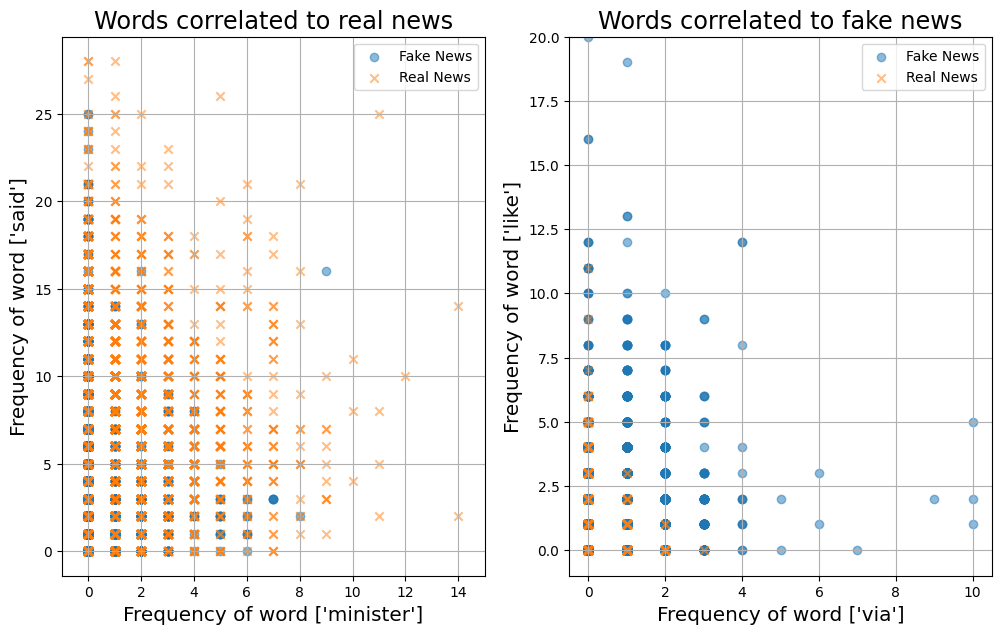

In [11]:
X = train_X_1
y = train_y_1
word_to_index = wti_1

real = y[:, 0] == 1
fake = y[:, 0] == 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,7))

# Words correlated to real news
feature_x_ax1 = 115
feature_y_ax1 = 2

ax1.scatter(X[fake, feature_x_ax1], X[fake, feature_y_ax1], marker = 'o', label = 'Fake News', alpha = 0.5)
ax1.scatter(X[real, feature_x_ax1], X[real, feature_y_ax1], marker = 'x', label = 'Real News', alpha = 0.5)

ax1.set_xlabel(f'Frequency of word {[k for k, v in word_to_index.items() if v == feature_x_ax1]}', fontsize = 'x-large')
ax1.set_ylabel(f'Frequency of word {[k for k, v in word_to_index.items() if v == feature_y_ax1]}', fontsize = 'x-large')
ax1.legend()
ax1.set_xlim(-1,15)
ax1.set_title('Words correlated to real news', fontsize = 'xx-large')
ax1.grid()

#Words correlated to fake news
feature_x_ax2 = 107
feature_y_ax2 = 30

ax2.scatter(X[fake, feature_x_ax2], X[fake, feature_y_ax2], marker = 'o', label = 'Fake News', alpha = 0.5)
ax2.scatter(X[real, feature_x_ax2], X[real, feature_y_ax2], marker = 'x', label = 'Real News', alpha = 0.5)

ax2.set_xlabel(f'Frequency of word {[k for k, v in word_to_index.items() if v == feature_x_ax2]}', fontsize = 'x-large')
ax2.set_ylabel(f'Frequency of word {[k for k, v in word_to_index.items() if v == feature_y_ax2]}', fontsize = 'x-large')
ax2.legend()
ax2.set_ylim(-1, 20)
ax2.set_title('Words correlated to fake news', fontsize = 'xx-large')
ax2.grid()

plt.show()

The features used in the plots are some of the highest ranking of each category, selected by hand to avoid those 'accuracy inflator' words. The plots use the known data (whether the article is real or fake), so that we can see if the model is classifying them right.

We can also plot the cost over the iterations to see the progress of the model until convergence:

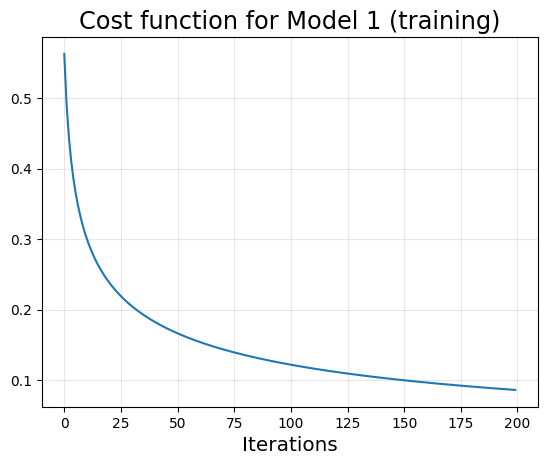

In [12]:
cost_history = train_cost_history_1

plt.plot(cost_history)
plt.title('Cost function for Model 1 (training)', fontsize = 'xx-large')
plt.xlabel('Iterations', fontsize = 'x-large')
plt.grid(alpha = 0.3)
plt.show()

# Next Steps

* Clean the list of words before picking the most common to remove the 'accuracy inflators'
* Build a second model on this updated list and compare its performance with the first one
* Test both models with the articles not used for training
* Compare the performance of both models (train accuracy vs test accuracy) and the test accuracy of one model vs the other

# Creating a second model on a clean list of most common words

In [13]:
def clean_data(articles, num_features, words_to_remove):
    all_words = []

    # Creates list of all the words of all the articles together
    for article in articles:
        words = article.split()
        all_words.extend(words) #'extend' adds to the existing list instead of appending a new list

    word_count = Counter(all_words) #dictionay of {word, frequency} pairs

    for word in words_to_remove:
        del word_count[word]
    
    features = [word for word, count in word_count.most_common(num_features)] 

    # Glossary of words
    word_to_idx = {
        word: i+1 for i, word in enumerate(features) #starts at 1, not 0, to match the input matrix X indices
    }

    return features, word_to_idx

In [30]:
words_to_remove = ['trump', 'u', 'clinton', 'obama', 'reuters', 'donald', 'united', 'hillary', 'democrat', 
                   'russia', 'democrat', 'republican', 'russian', 'politicsnews', 'china', 'politics', 'new', 'news',
                  'former', 'political', 'presidential', 'administration', 'democratic', 'worldnews', 'conservative', 
                  'york', 'korea', 'iran', 'syria', 'refugee', 'islamic', 'john', 'fox', 'sander', 'barack', 'cnn', 
                  'un', 'mr', 'gop', 'mexico', 'syrian', 'britain', 'liberal', 'saudi', 'iraq', 'putin', 'ryan', 'leftnews', 
                  'european', 'texas', 'florida', 'obamacare', 'israel', 'paul', 'turkey', 'germany', 'sunday',
                  'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'january', 'february', 
                  'march', 'april', 'may', 'june', 'july', 'august', 'september', 'october', 'november', 'december',
                  'fake', 'cruz', 'comey', 'bush', 'moscow', 'twitter', 'tweet', 'facebook', 'video', 'image',
                  'medium', 'post', 'reported', 'reporter', 'according', 'black', 'muslim', 'white', 'washington',
                  'george', 'house', 'party', 'eu', 'america', 'american', 'south', 'terrorist', 'month', 'man']

feat_2, wti_2 = clean_data(train_articles, num_features, words_to_remove)

train_X_2, train_y_2 = create_input_output(train_articles, train_labels, feat_2, wti_2)
train_m_2 = len(train_y_2)
train_n_2 = len(feat_2)

theta_2, train_cost_history_2 = logistic_regression(train_X_2, train_y_2)

## Compare performance between models

In [31]:
train_h_2 = hypothesis(train_X_2, theta_2)
train_pred_2 = (train_h_2 >= 0.5).astype(int) #1 for real news and 0 for fake news
train_acc_2 = np.mean(train_pred_2 == train_y_2)
print(f'Cleaned model has an accuracy of {train_acc_2 * 100:.2f}%, while the first model has an accuracy of {train_acc_1 * 100:.2f}%')

Cleaned model has an accuracy of 93.98%, while the first model has an accuracy of 98.65%


In [32]:
train_df_2 = create_df(feat_2, theta_2, 'Training_Results_Model2.csv')

display(train_df_2[:20])

,Words indicating Real,Weights,Words indicating Fake,Weights
1,said,0.62,via,-0.56
2,minister,0.31,like,-0.35
3,representative,0.20,even,-0.32
4,leader,0.16,know,-0.28
5,parliament,0.15,watch,-0.27
6,spokesman,0.15,get,-0.24
7,senate,0.14,time,-0.22
8,told,0.14,thing,-0.21
9,trade,0.14,go,-0.21
10,lawmaker,0.13,story,-0.21


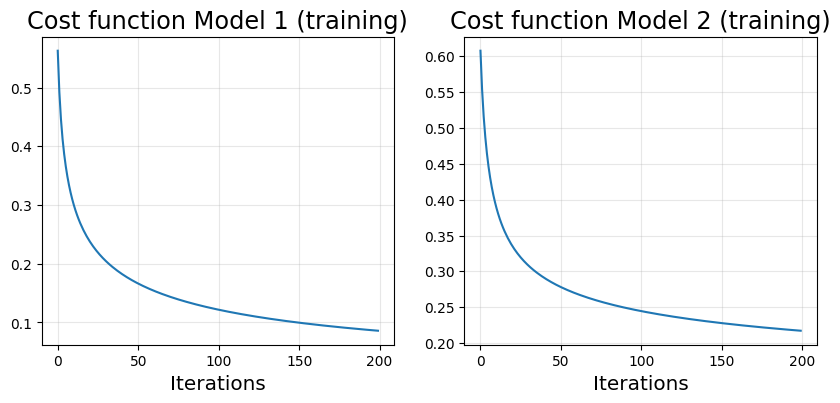

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 4))

ax1.plot(train_cost_history_1)
ax1.set_title('Cost function Model 1 (training)', fontsize = 'xx-large')
ax1.set_xlabel('Iterations', fontsize = 'x-large')
ax1.grid(alpha = 0.3)

ax2.plot(train_cost_history_2)
ax2.set_title('Cost function Model 2 (training)', fontsize = 'xx-large')
ax2.set_xlabel('Iterations', fontsize = 'x-large')
ax2.grid(alpha = 0.3)
plt.show()

By removing words that easily point to a fake or real new, the second model took more iterations to converge than the first model. It also caused a decrease in the accuracy.

# Testing the models

## Process test data

In [34]:
test_X_1, test_y_1 = create_input_output(test_articles, test_labels, feat_1, wti_1)
test_m_1 = len(test_y_1)
test_n_1 = len(feat_1)

In [35]:
test_X_2, test_y_2 = create_input_output(test_articles, test_labels, feat_2, wti_2)
test_m_2 = len(test_y_2)
test_n_2 = len(feat_2)

## Run test input for both models

In [36]:
test_h_1 = hypothesis(test_X_1, theta_1)
test_pred_1 = (test_h_1 >= 0.5).astype(int) #1 for real news and 0 for fake news
test_acc_1 = np.mean(test_pred_1 == test_y_1)
print(f'Model 1 has training accuracy of {train_acc_1 * 100:.2f}% and test accuracy of {test_acc_1 * 100:.2f}%')

Model 1 has training accuracy of 98.65% and test accuracy of 98.32%


In [37]:
test_h_2 = hypothesis(test_X_2, theta_2)
test_pred_2 = (test_h_2 >= 0.5).astype(int) #1 for real news and 0 for fake news
test_acc_2 = np.mean(test_pred_2 == test_y_2)
print(f'Model 2 has training accuracy of {train_acc_2 * 100:.2f}% and test accuracy of {test_acc_2 * 100:.2f}%')

Model 2 has training accuracy of 93.98% and test accuracy of 93.43%


The similar training and testing accuracies suggest that the model is successful in generalizing the information learned on training time to unseen data. One factor that might have helped such thing is the consistency between the data from train and test time: Since all articles were collected from a single dataset, their vocabulary and word frequency must be similar. As a result, the features that were useful to classify the articles during training remained useful during test time.

# Conclusion
This project explored the role of feature selection in classifying articles as real or fake news.

* Model 1 (Uncleaned): Utilized the 500 most frequent words from the raw dataset as features. While it achieved high accuracy (~98%), many features relied on domain-specific entities (such as names of public figures and specific US political context) rather than true linguistic or stylistic indicators.
* Model 2 (Cleaned): Removed context-bound words and improper features to focus on meaningful linguistic signals. Although overall accuracy decreased by roughly 5%, the remaining features reflect transferable textual patterns rather than topic-specific shortcuts.

## Key Observations
Both models maintained consistent performance between training and test sets, but for fundamentally different reasons:
* Model 2 achieved consistency because its cleaned feature set allows it to generalize well to unseen text.
* Model 1 achieved consistency because the train and test splits were drawn from the same dataset, meaning the superficial entity shortcuts learned during training were still present during testing.

## Future work
To rigorously evaluate whether Model 2 truly outperforms Model 1 in real-world scenarios, we must test both models on an out-of-domain dataset, for instance, on English-language European news. Because European coverage will lack the specific US-centric shortcuts Model 1 relied on, this experiment will reveal the true impact of feature cleaning on model validity.